<a href="https://colab.research.google.com/github/L-Pivetta/personal/blob/main/rete_neurale_tridimensionale_(caduta_pallina).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch

x = torch.tensor(
    [1.23, 44.15, 176.58, 313.92, 593.06, 828.61, 962.34, 1103],
    dtype=torch.float32
).unsqueeze(1)
y = torch.tensor(
    [0.5, 3.0, 6.0, 8.0, 11.0, 13.0, 14.0, 15.0],
    dtype=torch.float32
).unsqueeze(1)

x.shape

torch.Size([8, 1])

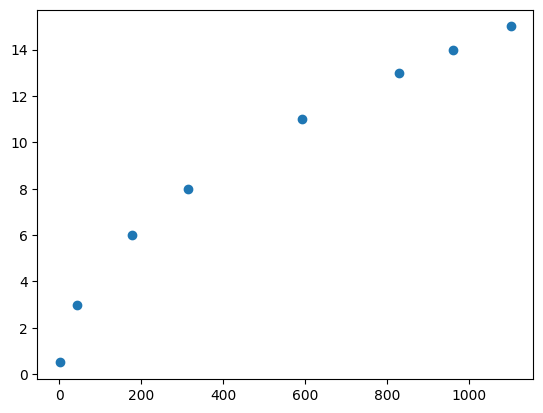

In [7]:
from matplotlib import pyplot
pyplot.scatter(x,y)

In [14]:
torch.manual_seed(42)

model = torch.nn.Sequential(
    torch.nn.Linear(1, 10),
    torch.nn.ReLU(),
    torch.nn.Linear(10, 10),
    torch.nn.ReLU(),
    torch.nn.Linear(10, 1),
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model(x)

tensor([[-3.9569e-02],
        [-3.2732e+00],
        [-1.3046e+01],
        [-2.3181e+01],
        [-4.3780e+01],
        [-6.1162e+01],
        [-7.1030e+01],
        [-8.1410e+01]], grad_fn=<AddmmBackward0>)

Epoch 0, Loss: 0.035495538264513016
Epoch 100, Loss: 0.0297367125749588
Epoch 200, Loss: 0.029242444783449173
Epoch 300, Loss: 0.04170267656445503
Epoch 400, Loss: 0.02985106036067009
Epoch 500, Loss: 0.029220152646303177
Epoch 600, Loss: 0.04364702105522156
Epoch 700, Loss: 0.029557405039668083
Epoch 800, Loss: 0.03351188823580742
Epoch 900, Loss: 0.031738270074129105
Epoch 1000, Loss: 0.029217692092061043
Epoch 1100, Loss: 0.2204868644475937
Epoch 1200, Loss: 0.02938717231154442
Epoch 1300, Loss: 0.029166100546717644
Epoch 1400, Loss: 0.03274069353938103
Epoch 1500, Loss: 0.029167981818318367
Epoch 1600, Loss: 0.04141540080308914
Epoch 1700, Loss: 0.029171446338295937
Epoch 1800, Loss: 0.16915975511074066
Epoch 1900, Loss: 0.2336391806602478
Epoch 2000, Loss: 0.02918093279004097
Epoch 2100, Loss: 0.029161471873521805
Epoch 2200, Loss: 0.02916148491203785
Epoch 2300, Loss: 0.029161537066102028
Epoch 2400, Loss: 0.02916153147816658
Epoch 2500, Loss: 0.029161473736166954
Epoch 2600, Los

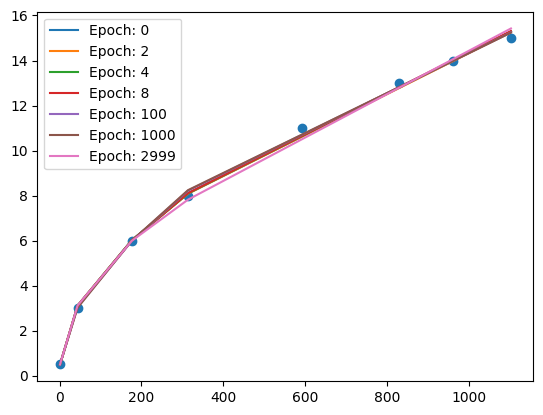

In [16]:
for epoch in range(3000):
  optimizer.zero_grad()
  y_pred = model(x)
  loss = loss_fn(y_pred, y)
  loss.backward()
  optimizer.step()
  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss: {loss}")
  if epoch in [0, 2, 4, 8, 100, 1000, 2999]:
    pyplot.plot(x, y_pred.detach(), label=f"Epoch: {epoch}")
pyplot.scatter(x, y)
pyplot.legend()

In [5]:
current_temperature = torch.tensor([70], dtype=torch.float32)
model(current_temperature)
for param in model.parameters():
  print(param)

Parameter containing:
tensor([[0.5537]], requires_grad=True)
Parameter containing:
tensor([-17.5949], requires_grad=True)
